In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input
from pathlib import Path
from tensorflow.keras.models import Sequential

In [ ]:
directory = Path("data")
train = directory / "train"
val = directory / "val"

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    labels = "inferred",
    shuffle = True,
    seed = 42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val,
    image_size = (224,224),
    batch_size = 32,
    label_mode = "binary",
    labels = "inferred",
    shuffle = False
)

Found 50937 files belonging to 2 classes.
Found 16980 files belonging to 2 classes.


In [ ]:
print("classes: ", train_ds.class_names)

classes:  ['awake', 'sleepy']


In [ ]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32, 1)
Image dtype: <dtype: 'float32'>
Pixel minimum: 2.1785736
Pixel maximum: 255.0


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

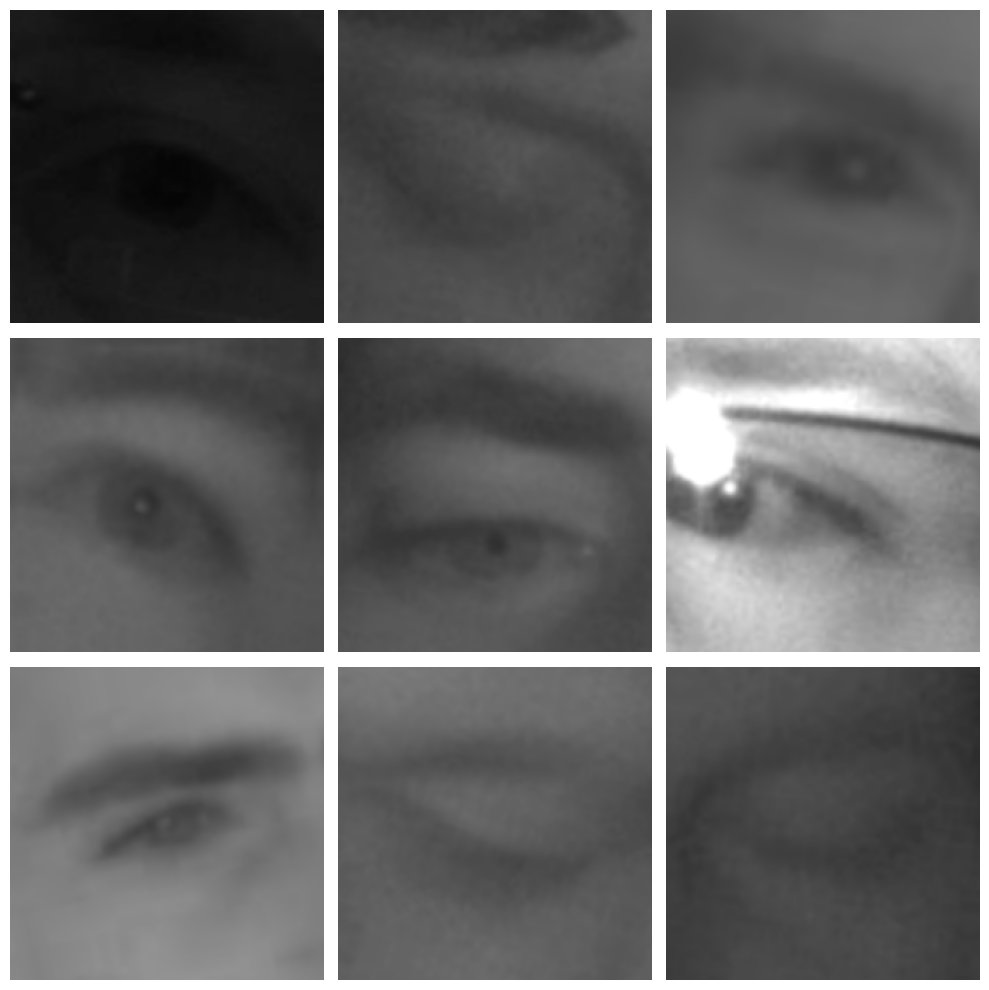

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i].numpy().astype("uint8"))
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=tf.data.AUTOTUNE
                        )

In [ ]:
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False
model = Sequential()
model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
    loss=tf.keras.losses.BinaryCrossentropy()
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)
callbakes = [early_stopping, checkpoint, reduce_lr]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbakes
)

Epoch 1/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 588s 350ms/step - accuracy: 0.9469 - loss: 0.1411 - val_accuracy: 0.9693 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 2/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 509s 320ms/step - accuracy: 0.9599 - loss: 0.1076 - val_accuracy: 0.9738 - val_loss: 0.0726 - learning_rate: 0.0010
Epoch 3/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 509s 320ms/step - accuracy: 0.9622 - loss: 0.1019 - val_accuracy: 0.9696 - val_loss: 0.0765 - learning_rate: 0.0010
Epoch 4/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 517s 325ms/step - accuracy: 0.9643 - loss: 0.0961 - val_accuracy: 0.9768 - val_loss: 0.0613 - learning_rate: 0.0010
Epoch 5/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 524s 329ms/step - accuracy: 0.9664 - loss: 0.0906 - val_accuracy: 0.9743 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 6/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 559s 327ms/step - accuracy: 0.9660 - loss: 0.0908 - val_accuracy: 0.9771 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 7/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 553s 322ms

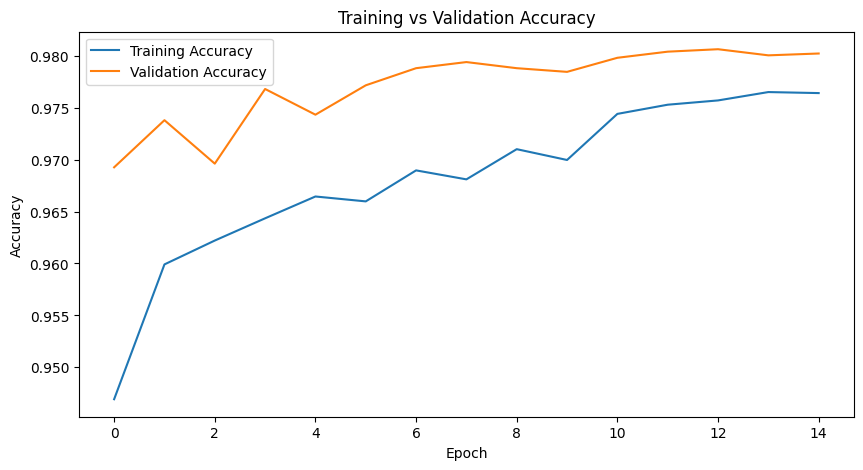

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

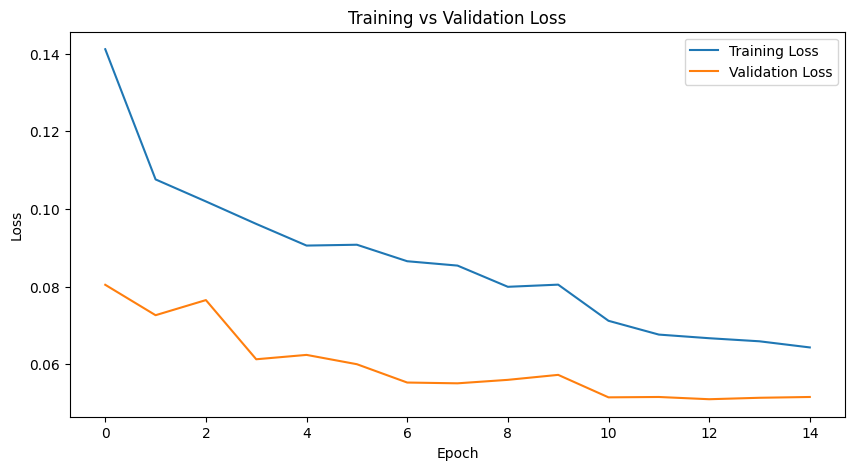

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,541,864 (17.33 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 328,196 (1.25 MB)

In [ ]:
model = tf.keras.models.load_model("best_model.keras")

In [ ]:
base_model = model.get_layer("efficientnetb0")
base_model.tranable = True
tune = int(len(base_model.layers)*0.7)
for layer in base_model.layers[:tune]:
  layer.trainable = False

for layer in base_model.layers[tune:]:
  layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=["accuracy"],
    loss=tf.keras.losses.BinaryCrossentropy()
)
fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "MRL_fineTuned.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True
)

fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    mode="min",
    restore_best_weights=True
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    mode="min"
)
callback = [fine_tune_checkpoint, fine_tune_early_stopping, fine_tune_reduce_lr]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callback
)

Epoch 1/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 651s 384ms/step - accuracy: 0.9773 - loss: 0.0669 - val_accuracy: 0.9835 - val_loss: 0.0420 - learning_rate: 1.0000e-04
Epoch 2/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 561s 352ms/step - accuracy: 0.9844 - loss: 0.0456 - val_accuracy: 0.9882 - val_loss: 0.0357 - learning_rate: 1.0000e-04
Epoch 3/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 559s 351ms/step - accuracy: 0.9860 - loss: 0.0408 - val_accuracy: 0.9892 - val_loss: 0.0324 - learning_rate: 1.0000e-04
Epoch 4/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 553s 347ms/step - accuracy: 0.9874 - loss: 0.0365 - val_accuracy: 0.9881 - val_loss: 0.0340 - learning_rate: 1.0000e-04
Epoch 5/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 560s 351ms/step - accuracy: 0.9880 - loss: 0.0339 - val_accuracy: 0.9900 - val_loss: 0.0302 - learning_rate: 1.0000e-04
Epoch 6/15
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 553s 347ms/step - accuracy: 0.9889 - loss: 0.0310 - val_accuracy: 0.9901 - val_loss: 0.0319 - learning_rate: 1.0000e-04
Epoch 7/15
1592/1592 ━━━━━━━

In [20]:
best_model = tf.keras.models.load_model("MRL_fineTuned.keras")
acuurary = best_model.evaluate(val_ds)

531/531 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.9900 - loss: 0.0302


In [23]:
print(f"Best Model: MRL_fineTuned.keras")

print(f"Accuracy of final Model: {acuurary[1]*100:.2f}%")

Best Model: MRL_fineTuned.keras
Accuracy of final Model: 99.00%
